In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches
import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata.obs['progression'] = adata.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})

In [3]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_tnk_annotation_new.h5ad')

In [4]:
adata_t.obs['original_index'] = adata_t.obs_names
lst = adata_t.obs['original_index'].astype(str).str.split('-')
adata_t.obs['original_index_split'] = list(zip(*lst))[0]
adata_t.obs_names = adata_t.obs['sample'].astype(str) + '_' + adata_t.obs['original_index_split']

In [5]:
temp_index = pd.DataFrame(adata_t.obs['original_index']).reset_index()
temp_index.index = temp_index['original_index']
index_dict = temp_index.to_dict()['index']

In [6]:
adata = adata[adata.obs['annot_final'].isin([
 'CD8 Tem Cell',
 'Tactiv Cell',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'Terminal CD8 Tex Cell'
])]

In [7]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_4088/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [8]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [9]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# B - F1

In [10]:
adata_bf1 = adata[adata.obs['timepoint'].isin(['B','F1'])]

In [11]:
clonotype_counts_b = adata_bf1[adata_bf1.obs['timepoint'] == 'B'].obs['clonotype_patient'].value_counts()
clonotype_counts_f1 = adata_bf1[adata_bf1.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()

In [12]:
clonotype_counts_b

11840_E25    83
10475_E15    76
9895_E30     70
3931_E31     60
18991_E20    59
             ..
17231_E18     1
17233_E18     1
17235_E18     1
17239_E18     1
9101_E23      1
Name: clonotype_patient, Length: 11248, dtype: int64

In [13]:
clonotype_counts_bf1 = pd.concat([clonotype_counts_b,
                                  clonotype_counts_f1],axis=1)
clonotype_counts_bf1 = clonotype_counts_bf1.dropna()
clonotype_counts_bf1.columns = ['B','F1']

In [14]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [15]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [16]:
b_props = []
f1_props = []
for i in clonotype_counts_bf1.index:
    temp = i.split('_')[1]
    b_count = sample_counts.loc[temp + '_B','T cells']
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    b_props.append(clonotype_counts_bf1.loc[i,'B'] / b_count)
    f1_props.append(clonotype_counts_bf1.loc[i,'F1'] / f1_count)

In [17]:
clonotype_counts_bf1_norm = pd.DataFrame({'B' : b_props,
                                          'F1' : f1_props},index=clonotype_counts_bf1.index)

In [18]:
expanding_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'F1'] - .001) >= clonotype_counts_bf1_norm.loc[i,'B']]
contracting_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'B'] - .001) >= clonotype_counts_bf1_norm.loc[i,'F1']]

In [19]:
expanding_clones_bf1 = expanding_clones
contracting_clones_bf1 = contracting_clones
nonexpanding_clones_bf1 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]
shared_clones_bf1 = clonotype_counts_bf1_norm.index.tolist()

In [20]:
dist_b = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)
dist_f1 = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)

# F1 - F2

In [21]:
adata_f1f2 = adata[adata.obs['timepoint'].isin(['F1','F2'])]

In [22]:
clonotype_counts_f1 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()
clonotype_counts_f2 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F2'].obs['clonotype_patient'].value_counts()

In [23]:
clonotype_counts_f1f2 = pd.concat([clonotype_counts_f1,
                                  clonotype_counts_f2],axis=1)
clonotype_counts_f1f2 = clonotype_counts_f1f2.dropna()
clonotype_counts_f1f2.columns = ['F1','F2']

In [24]:
f1_props = []
f2_props = []
for i in clonotype_counts_f1f2.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f1_props.append(clonotype_counts_f1f2.loc[i,'F1'] / f1_count)
    f2_props.append(clonotype_counts_f1f2.loc[i,'F2'] / f2_count)

In [25]:
clonotype_counts_f1f2_norm = pd.DataFrame({'F1' : f1_props,
                                           'F2' : f2_props},index=clonotype_counts_f1f2.index)

In [26]:
expanding_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F2'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F1']]
contracting_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F1'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F2']]

In [27]:
expanding_clones_f1f2 = expanding_clones
contracting_clones_f1f2 = contracting_clones
nonexpanding_clones_f1f2 = [i for i in clonotype_counts_f1f2_norm.index if i not in expanding_clones]
shared_clones_f1f2 = clonotype_counts_f1f2_norm.index.tolist()

In [28]:
status = []
patient = []
progression = []
clonotype_counts_f1f2_norm_progression = clonotype_counts_f1f2_norm.copy()
del clonotype_counts_f1f2_norm_progression['F1']
del clonotype_counts_f1f2_norm_progression['F2']
for i in clonotype_counts_f1f2_norm_progression.index:
    if i in expanding_clones_f1f2:
        status.append('expanded')
    elif i in contracting_clones_f1f2:
        status.append('contract')
    else:
        status.append('stable')
    patient.append(i.split('_')[1])
    progression.append(patient_progression[i.split('_')[1]])

In [29]:
clonotype_counts_f1f2_norm_progression['status'] = status
clonotype_counts_f1f2_norm_progression['patient'] = patient
clonotype_counts_f1f2_norm_progression['progression'] = progression

# All timepoints shared

In [30]:
all_timepoints_shared = list(set(shared_clones_bf1) & set(shared_clones_f1f2))

In [31]:
slow_expanding_b_barcodes = adata[(adata.obs['clonotype_patient'].isin(all_timepoints_shared)) & (
    adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell') & (
    adata.obs['timepoint'].isin(['B'])) & (
    adata.obs['progression'] == 'Slow'
    )].obs_names
slow_expanding_f1_barcodes = adata[(adata.obs['clonotype_patient'].isin(all_timepoints_shared)) & (
    adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell') & (
    adata.obs['timepoint'].isin(['F1'])) & (
    adata.obs['progression'] == 'Slow'
    )].obs_names
slow_expanding_f2_barcodes = adata[(adata.obs['clonotype_patient'].isin(all_timepoints_shared)) & (
    adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell') & (
    adata.obs['timepoint'].isin(['F2'])) & (
    adata.obs['progression'] == 'Slow'
    )].obs_names
fast_expanding_b_barcodes = adata[(adata.obs['clonotype_patient'].isin(all_timepoints_shared)) & (
    adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell') & (
    adata.obs['timepoint'].isin(['B'])) & (
    adata.obs['progression'] == 'Fast'
    )].obs_names
fast_expanding_f1_barcodes = adata[(adata.obs['clonotype_patient'].isin(all_timepoints_shared)) & (
    adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell') & (
    adata.obs['timepoint'].isin(['F1'])) & (
    adata.obs['progression'] == 'Fast'
    )].obs_names
fast_expanding_f2_barcodes = adata[(adata.obs['clonotype_patient'].isin(all_timepoints_shared)) & (
    adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell') & (
    adata.obs['timepoint'].isin(['F2'])) & (
    adata.obs['progression'] == 'Fast'
    )].obs_names

In [32]:
expanding_barcodes_df = pd.DataFrame(pd.concat([pd.Series(slow_expanding_f1_barcodes),
                                                pd.Series(slow_expanding_f2_barcodes),
                                                pd.Series(fast_expanding_f1_barcodes),
                                                pd.Series(fast_expanding_f2_barcodes),]))
expanding_barcodes_df['identity'] = pd.concat([
    pd.Series(['Slow B-F1-F2 Shared Tpex at F1'] * len(slow_expanding_f1_barcodes)),
    pd.Series(['Slow B-F1-F2 Shared Tpex at F2'] * len(slow_expanding_f2_barcodes)),
    pd.Series(['Fast B-F1-F2 Shared Tpex at F1'] * len(fast_expanding_f1_barcodes)),
    pd.Series(['Fast B-F1-F2 Shared Tpex at F2'] * len(fast_expanding_f2_barcodes)),])

In [33]:
other_barcodes_df = pd.DataFrame(pd.concat([pd.Series(slow_expanding_b_barcodes),
                                                pd.Series(slow_expanding_f1_barcodes),
                                                pd.Series(slow_expanding_f2_barcodes),
                                                pd.Series(fast_expanding_b_barcodes),
                                                pd.Series(fast_expanding_f1_barcodes),
                                                pd.Series(fast_expanding_f2_barcodes),]))
other_barcodes_df['identity'] = pd.concat([
    pd.Series(['Slow B-F1-F2 Shared Tpex at B'] * len(slow_expanding_b_barcodes)),
    pd.Series(['Slow B-F1-F2 Shared Tpex at F1'] * len(slow_expanding_f1_barcodes)),
    pd.Series(['Slow B-F1-F2 Shared Tpex at F2'] * len(slow_expanding_f2_barcodes)),
    pd.Series(['Fast B-F1-F2 Shared Tpex at B'] * len(fast_expanding_b_barcodes)),
    pd.Series(['Fast B-F1-F2 Shared Tpex at F1'] * len(fast_expanding_f1_barcodes)),
    pd.Series(['Fast B-F1-F2 Shared Tpex at F2'] * len(fast_expanding_f2_barcodes)),])

In [34]:
expanding_barcodes_df.index = expanding_barcodes_df['sample_index']
del expanding_barcodes_df['sample_index']

other_barcodes_df.index = other_barcodes_df['sample_index']
del other_barcodes_df['sample_index']

In [35]:
adata_t.obs['slow_f1f2_expanding_tpex'] = expanding_barcodes_df['identity']
adata.obs['slow_f1f2_expanding_tpex'] = expanding_barcodes_df['identity']

adata_t.obs['slow_f1f2_other_tpex'] = other_barcodes_df['identity']
adata.obs['slow_f1f2_other_tpex'] = other_barcodes_df['identity']

In [36]:
adata_t.obs['slow_f1f2_other_tpex'].value_counts()

Slow B-F1-F2 Shared Tpex at F1    1309
Slow B-F1-F2 Shared Tpex at F2    1153
Slow B-F1-F2 Shared Tpex at B     1142
Fast B-F1-F2 Shared Tpex at F1     412
Fast B-F1-F2 Shared Tpex at F2     378
Fast B-F1-F2 Shared Tpex at B      157
Name: slow_f1f2_other_tpex, dtype: int64

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


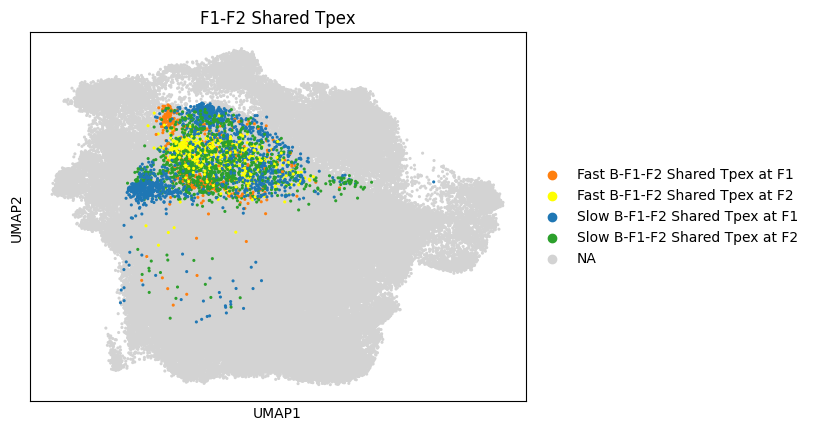

In [37]:
sc.pl.umap(adata_t,color='slow_f1f2_expanding_tpex',size=20,title='F1-F2 Shared Tpex',
          palette={'Slow B-F1-F2 Shared Tpex at F1' : 'tab:blue',
                   'Slow B-F1-F2 Shared Tpex at F2' : 'tab:green',
                   'Fast B-F1-F2 Shared Tpex at F1' : 'tab:orange',
                   'Fast B-F1-F2 Shared Tpex at F2' : 'yellow',
                  })

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


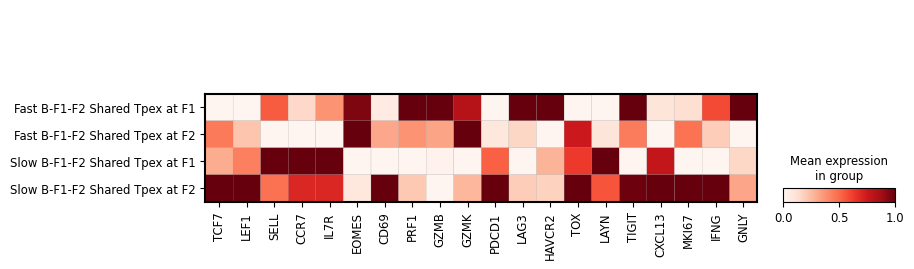

In [38]:
sc.pl.matrixplot(adata[~adata.obs['slow_f1f2_expanding_tpex'].isnull()],
              ['TCF7','LEF1','SELL','CCR7','IL7R','EOMES',
                'CD69','PRF1','GZMB',
                'GZMK','PDCD1','LAG3','HAVCR2','TOX',
                'LAYN','TIGIT','CXCL13','MKI67','IFNG','GNLY'],
             groupby='slow_f1f2_expanding_tpex',standard_scale='var',cmap='Reds')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


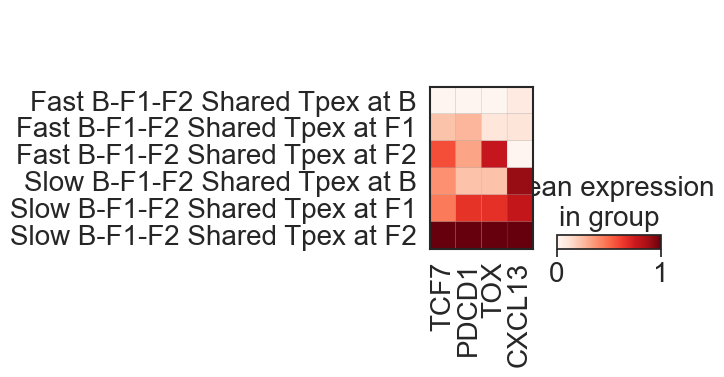

In [39]:
sns.set(font_scale=2)
sns.set_style('white')
sc.pl.matrixplot(adata[~adata.obs['slow_f1f2_other_tpex'].isnull()],
              ['TCF7', 'PDCD1', 'TOX', 'CXCL13'],
             groupby='slow_f1f2_other_tpex',standard_scale='var',cmap='Reds',
                save='tpex_subsetted_markers.pdf')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250110/tpex_subsetted_markers.pdf')